## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


In [2]:
path = '..\\data\\segment_alerts_all_airports_train.csv'
df = pd.read_csv(path)
print(f'Shape : {df.shape}')
IDS = ['lightning_id','lightning_airport_id','date','lon','lat','airport','airport_alert_id']
df.head()

Shape : (507071, 13)


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [3]:
import matplotlib.gridspec as gridspec
def desc_stats(col):
    s = df[col]
    n_total = len(s)
    n_missing = s.isna().sum()
    pct_missing = n_missing / n_total * 100
    
    print(f"=== {col} ===")
    print(f"Manquants     : {n_missing} ({pct_missing:.2f}%)")
    print()
    print(s.describe().to_string())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(col, fontsize=13)
    
    # Histogramme + KDE
    s.dropna().plot.hist(ax=axes[0], bins=50, color="steelblue", edgecolor="white")
    axes[0].set_title("Distribution")
    axes[0].set_xlabel(col)
    
    # Boxplot
    s.dropna().plot.box(ax=axes[1], color="steelblue")
    axes[1].set_title("Boxplot")
    
    # Barre missings
    if n_missing > 0:
        for ax in axes:
            ax.set_xlabel(f"{ax.get_xlabel()}\n({pct_missing:.1f}% manquants)")
    
    plt.tight_layout()
    plt.show()


In [4]:
# 2.1 — Types & parsing
VAR = ['dist','azimuth']
df['date'] = pd.to_datetime(df['date'], utc=True)
df['icloud'] = df['icloud'].astype(bool)
df['is_last_lightning_cloud_ground'] = df['is_last_lightning_cloud_ground'].astype('boolean')

# 2.2 — Variables temporelles
df['year']   = df['date'].dt.year
df['month']  = df['date'].dt.month
df['hour']   = df['date'].dt.hour
df['season'] = df['month'].map({
    12:'Hiver', 1:'Hiver', 2:'Hiver',
    3:'Printemps', 4:'Printemps', 5:'Printemps',
    6:'Été', 7:'Été', 8:'Été',
    9:'Automne', 10:'Automne', 11:'Automne'
})
df = df.sort_values(["airport", "date"])
VAR += ['month','hour']
# index reset
df = df.reset_index(drop=True)
# 2.3 — Alerte Pise 2016 (données intra-nuage potentiellement biaisées)
mask_pise_2016 = (df['airport'] == 'Pise') & (df['year'] == 2016) & (df['icloud'] == True)
print(f"⚠️  Éclairs intra-nuage Pise 2016 : {mask_pise_2016.sum()} (à exclure si analyse icloud)")
df_clean = df#.copy()#[~mask_pise_2016]

# 2.4 — Sous-ensembles utiles
df_20km  = df_clean[df_clean['dist'] <= 20].copy()   # zone opérationnelle
df_cg    = df_clean[df_clean['icloud'] == False].copy()  # éclairs nuage-sol uniquement
df_cg_20 = df_cg[df_cg['dist'] <= 20].copy()

print(f"\nDataset nettoyé     : {df_clean.shape[0]:,} éclairs")
print(f"Éclairs ≤ 20 km     : {df_20km.shape[0]:,}")
print(f"Éclairs nuage-sol   : {df_cg.shape[0]:,}")
print(f"CG ≤ 20 km          : {df_cg_20.shape[0]:,}")

⚠️  Éclairs intra-nuage Pise 2016 : 19404 (à exclure si analyse icloud)

Dataset nettoyé     : 507,071 éclairs
Éclairs ≤ 20 km     : 220,498
Éclairs nuage-sol   : 128,992
CG ≤ 20 km          : 56,599


## Temps depuis les derniers éclairs

In [ ]:
# temps depuis le dernier éclair (tous types)
df["time_since_last_lightning"] = (
    df.groupby("airport")["date"]
    .diff()
    .dt.total_seconds()
)


# temps depuis le dernier éclair nuage-sol
df["date_cg"] = df["date"].where(df["icloud"] == False)

df["time_since_last_cloud_ground"] = (
    df.groupby("airport")["date_cg"]
    .ffill()
)

df["time_since_last_cloud_ground"] = (
    df["date"] - df["time_since_last_cloud_ground"]
).dt.total_seconds()



# temps depuis le dernier éclair intra-nuage
df["date_ic"] = df["date"].where(df["icloud"] == True)

df["time_since_last_intra_cloud"] = (
    df.groupby("airport")["date_ic"]
    .ffill()
)

df["time_since_last_intra_cloud"] = (
    df["date"] - df["time_since_last_intra_cloud"]
).dt.total_seconds()
###########################################################################
df["time_since_last_lightning"] = df["time_since_last_lightning"].fillna(0)
lightning_mask = df["time_since_last_lightning"]>=3600
df["time_since_last_intra_cloud"] = df["time_since_last_intra_cloud"].fillna(0)
df["time_since_last_cloud_ground"] = df["time_since_last_cloud_ground"].fillna(0)


=== time_since_last_cloud_ground ===
Manquants     : 16 (0.00%)

count    5.070550e+05
mean     5.159420e+03
std      1.022663e+05
min      0.000000e+00
25%      0.000000e+00
50%      7.000000e+00
75%      3.400000e+01
max      1.488929e+07


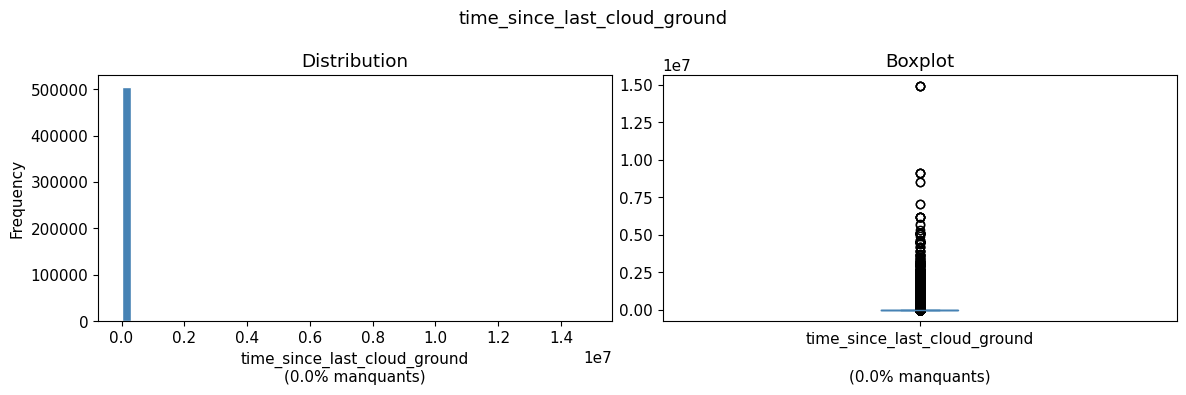

In [6]:
col = "time_since_last_cloud_ground"
desc_stats(col)

In [6]:
# Censurer les durées au delà d un seuil, fixé ici à 1h
###########################################################################################
df["time_since_last_cloud_ground2"] = np.log(df["time_since_last_cloud_ground"].clip(0,3600)+1)
df["time_since_last_intra_cloud2"]= np.log(df["time_since_last_intra_cloud"].clip(0,3600).fillna(0)+1)
df["time_since_last_lightning2"] = np.log(df["time_since_last_lightning"].clip(0,3600).fillna(0)+1)
VAR.append("time_since_last_lightning2")
VAR.append("time_since_last_intra_cloud2")
VAR.append("time_since_last_cloud_ground2")


In [7]:
# col = "dist"
# #df[col] = df[col].fillna(0)
# desc_stats(col)

## Nombre d’éclairs récents (fenêtres temporelles)

In [8]:
df = df.set_index("date")

# nombre d'éclairs dans différentes fenêtres
for window in ["1min", "5min", "10min", "20min", "30min"]:
    
    df[f"count_{window}"] =(
        df.groupby("airport")["lightning_id"]
        .rolling(window)
        .count()
        .reset_index(level=0, drop=True)
    )
    df[f"log_count_{window}"] =  np.log(df[f"count_{window}"]+1)
    VAR.append(f"log_count_{window}")

## Comptage par type d’éclair

In [9]:
# éclairs nuage-sol
df["cg"] = (df["icloud"] == False).astype(int)
# éclairs intra-nuage
df["ic"] = (df["icloud"] == True).astype(int)

for window in ["5min", "10min", "20min"]:
    df[f"ic_count_{window}"] = (
        df.groupby("airport")["ic"]
        .rolling(window)
        .sum()
        .reset_index(level=0, drop=True)
    )
    df[f"cg_count_{window}"] = (
        df.groupby("airport")["cg"]
        .rolling(window)
        .sum()
        .reset_index(level=0, drop=True)
    )
    df[f"log_ic_count_{window}"] = np.log(df[f"ic_count_{window}"]+1)
    df[f"log_cg_count_{window}"] = np.log(df[f"cg_count_{window}"]+1)
    VAR+=[f"log_ic_count_{window}", f"log_cg_count_{window}"]

=== log_ic_count_10min ===
Manquants     : 0 (0.00%)

count    507071.000000
mean          4.229013
std           1.640422
min           0.000000
25%           3.218876
50%           4.543295
75%           5.521461
max           7.331060


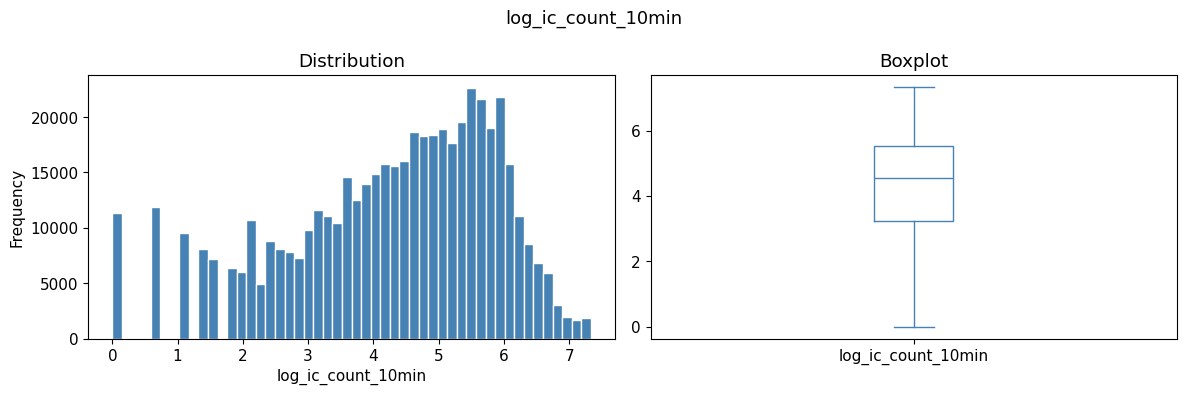

In [10]:
col = "log_ic_count_10min"
#df[col] = df[col].fillna(0)
desc_stats(col)

## Taux d'activité

In [11]:
df["rate_1min"] = df["count_1min"]
df["rate_5min"] = df["count_5min"] / 5
df["rate_10min"] = df["count_10min"] / 10

df["rate_trend"] = np.log(df["count_10min"] - df["count_5min"]+1)

df["activity_decay"] = df["rate_5min"] / (df["rate_10min"] + 1e-6)

VAR+=["rate_trend","activity_decay"]

## Variable spatiale

In [12]:
for window in ["1min", "5min", "10min"]:
    
    df[f"mean_dist_{window}"] = (
        df.groupby("airport")["dist"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    df[f"min_dist_{window}"] = (
        df.groupby("airport")["dist"]
        .rolling(window)
        .min()
        .reset_index(level=0, drop=True)
    )
    VAR+=[f"mean_dist_{window}",f"min_dist_{window}"] 

df["distance_trend"] = df["mean_dist_1min"] - df["mean_dist_10min"]
#dispersion spatiale

df["std_lat_10min"] = (
    df.groupby("airport")["lat"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)

df["std_lon_10min"] = (
    df.groupby("airport")["lon"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)

VAR+=["distance_trend","std_lat_10min","std_lon_10min","azimuth_change"]
#direction du front orageux
# les NA dans std_azimuth_ sont dus à une absence de valeurs dans la fenetre emporelle
# l imputation par 0 prends tout son sens
###################################################################
df["std_lon_10min"] = df["std_lon_10min"].fillna(0)
df["std_lat_10min"] = df["std_lat_10min"].fillna(0)
for window in ["1min", "10min"]:
    df[f"mean_azimuth_{window}"] = (
        df.groupby("airport")["azimuth"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"std_azimuth_{window}"] = (
        df.groupby("airport")["azimuth"]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )
    df[f"std_azimuth_{window}"] = df[f"std_azimuth_{window}"].fillna(0)
    VAR+=[f"mean_azimuth_{window}",f"std_azimuth_{window}"]

df["azimuth_change"] = df["mean_azimuth_1min"] - df["mean_azimuth_10min"]

=== azimuth_change ===
Manquants     : 0 (0.00%)

count    507071.000000
mean         -3.363007
std          28.811422
min        -314.727072
25%         -11.150848
50%          -1.535720
75%           5.863439
max         308.090097


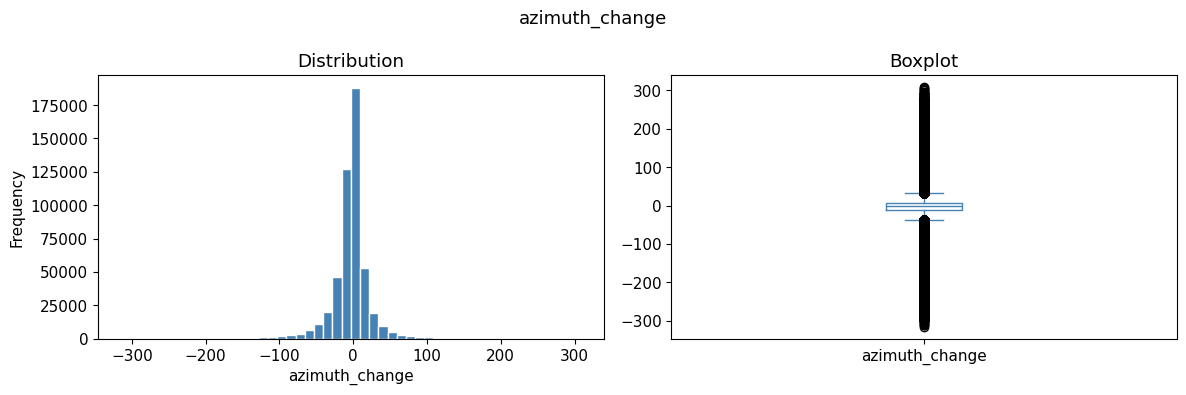

In [13]:
col = "azimuth_change"
desc_stats(col)

## intensité électrique

In [14]:
for window in ["1min", "10min"]:
    df[f"mean_amplitude_{window}"] = (
        df.groupby("airport")["amplitude"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"max_amplitude_{window}"] = (
        df.groupby("airport")["amplitude"]
        .rolling(window)
        .max()
        .reset_index(level=0, drop=True)
    )
    VAR+=[f"mean_amplitude_{window}",f"max_amplitude_{window}"]

df["amplitude_change"] = df["mean_amplitude_1min"] - df["mean_amplitude_10min"]

df["std_amplitude_10min"] = (
    df.groupby("airport")["amplitude"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)
###################################################################
df["log_std_amplitude_10min"] = np.log(df["std_amplitude_10min"].fillna(0)+1)
VAR+=["amplitude_change","log_std_amplitude_10min"]

## Durée d alerte

In [15]:
#ratio nuage-sol
df["cg_ratio"] = df["cg_count_10min"] / (df["count_10min"] + 1e-6)
#burst d’éclairs
df["burst_indicator"] = (df["count_1min"] > 5).astype(int)
df["date"] = pd.to_datetime(df.index, utc=True)
#durée d'alerte
df["alert_start"] = (
    df.groupby(["airport", "airport_alert_id"])["date"]
    .transform("min")
)


df["alert_duration"] = (
    df.index - df["alert_start"]
).dt.total_seconds()
#########################################################
df["alert_duration"] = df["alert_duration"].fillna(0).clip(0,3600)
#df = df.reset_index()
VAR+= ["cg_ratio","burst_indicator","alert_duration"]

## Vitesse de déplacement de l’orage

In [16]:
# différence temporelle entre éclairs
df["delta_t"] = (
    df.groupby("airport")["date"]
    .diff()
    .dt.total_seconds()
)

# déplacement spatial approximatif
df["delta_dist"] = df.groupby("airport")["dist"].diff()

# vitesse radiale (km/sec)
df["storm_velocity"] = df["delta_dist"] / (df["delta_t"] + 1e-6)

VAR+=["delta_dist","storm_velocity"]
# par soucis de coherence, pour des éclairs avec plus d une heure d écart, la variation de distance passera à 0
bol = df["time_since_last_lightning"]>=3600
df.loc[bol,["delta_dist","storm_velocity"]] = 0
df.loc[:,["delta_dist","storm_velocity"]] = df.loc[:,["delta_dist","storm_velocity"]].fillna(0)

## Accélération de l’activité électrique

In [17]:
# variation du taux d'activité
df["activity_acceleration"] = (
    df["rate_1min"] - df["rate_5min"]
)
# df["activity_trend"] = (
#     df["count_10min"]- df["count_5min"]
# )
VAR+=["activity_acceleration"]

=== activity_acceleration ===
Manquants     : 0 (0.00%)

count    507071.000000
mean          0.963427
std           5.275369
min         -45.400000
25%          -1.000000
50%           0.800000
75%           2.800000
max          68.800000


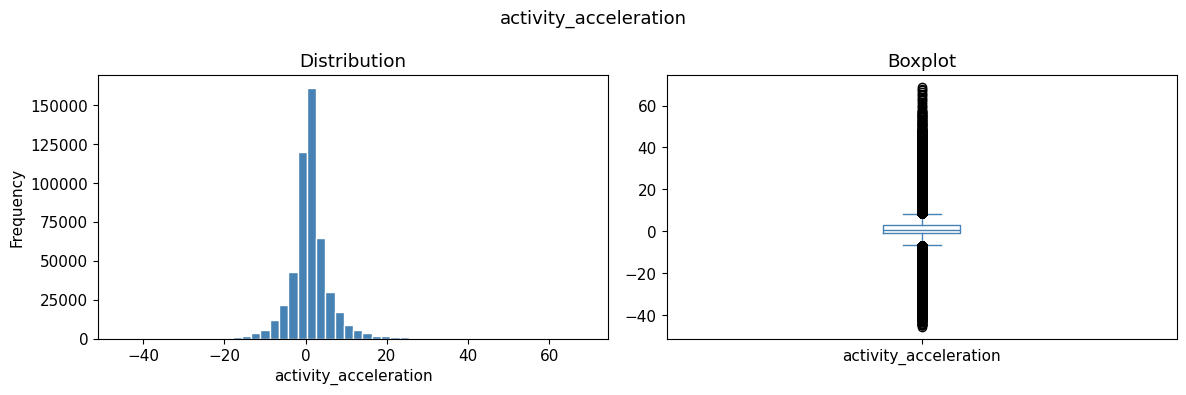

In [18]:
col = "activity_acceleration"
#df[col] = df[col].fillna(0)
desc_stats(col)

## Silence time

In [19]:
# indicateurs de silence prolongé
df["silence_30min"] = (df["time_since_last_lightning"] > 1800).astype(int)
VAR+=["silence_30min"]


## direction du déplacement

In [20]:
df["azimuth_diff"] = df.groupby("airport")["azimuth"].diff()
######################################################
df["azimuth_diff"] = df["azimuth_diff"].fillna(0)
lightning_mask = df['time_since_last_lightning']>=3600
df.loc[lightning_mask,'azimuth_diff'] = 0
df["storm_direction_change"] = np.log(df["azimuth_diff"].abs()+1)
VAR+=["azimuth_diff","storm_direction_change"]

## Distance du centre de l’orage à l’aéroport

In [21]:
# centre de masse des éclairs dans les 10 dernières minutes

df["storm_lat_center"] = (
    df.groupby("airport")["lat"]
    .rolling("10min")
    .mean()
    .reset_index(level=0, drop=True)
)

df["storm_lon_center"] = (
    df.groupby("airport")["lon"]
    .rolling("10min")
    .mean()
    .reset_index(level=0, drop=True)
)

# récupérer coordonnées
df["airport_lat"] = df["airport"].map(lambda x: AIRPORT_COORDS[x][0])
df["airport_lon"] = df["airport"].map(lambda x: AIRPORT_COORDS[x][1])

# distance euclidienne simple (approximation locale)

df["storm_center_distance"] = np.sqrt(
    (df["storm_lat_center"] - df["airport_lat"])**2 +
    (df["storm_lon_center"] - df["airport_lon"])**2
)

# déplacement du centre
df["storm_center_move"] = (
    df.groupby("airport")["storm_center_distance"]
    .diff()
)
#########################################
df["storm_center_move"] = df["storm_center_move"].fillna(0)
df.loc[lightning_mask,"storm_center_move"] = 0
# vitesse (distance / temps)

df["storm_center_velocity"] = (
    df["storm_center_move"] /(
    df["time_since_last_lightning"] + 1)
)
df["storm_spread"] = (
    df["std_lat_10min"] + df["std_lon_10min"]
)
VAR+=["storm_center_velocity","storm_spread","storm_center_distance","storm_center_move"]

# Création de la target : temps jusqu’au prochain éclair

In [22]:
# éclair nuage-sol
df["is_cloud_ground"] = 1*(df["icloud"] == False)

# 1️⃣ identifier les éclairs cloud-ground dans 20 km
df["cg_20km"] = (
    (~df["icloud"]) &
    (df["dist"] <= 20)
)

# 2️⃣ créer une colonne avec date seulement pour ces événements
df["cg20_date"] = df["date"].where(df["cg_20km"])

# 3️⃣ prochain événement dans chaque aéroport
df["next_cg20_date"] = (
    df.groupby("airport")["cg20_date"]
    .bfill()
)

# 4️⃣ temps jusqu'au prochain éclair
df["time_to_next_cg20"] = (
    df["next_cg20_date"] - df["date"]
).dt.total_seconds()

df["time_to_next_cg20"]  = df["time_to_next_cg20"].clip(0,3600)
# 5️⃣ supprimer les lignes sans événement futur
df = df[df["time_to_next_cg20"].notna()]


VAR+=["is_cloud_ground","cg_20km"]
TARGET = ["time_to_next_cg20"]


In [23]:
# Transformation logarithmique
df["target_log_time"] = np.log(df["time_to_next_cg20"]+1)# np.log1p(df["time_to_next_cg20"])# pred_time = np.expm1(pred_log)

# Transformation par classes temporelles
bins = [0, 300, 600, 1200, 1800, np.inf] # en secondes

labels = [0,1,2,3,4]

df["target_bins"] = pd.cut(
    df["time_to_next_cg20"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
TARGET+=["target_log_time","target_bins"]

=== target_log_time ===
Manquants     : 0 (0.00%)

count    507034.000000
mean          3.724461
std           2.463647
min           0.000000
25%           1.945910
50%           3.583519
75%           5.451038
max           8.188967


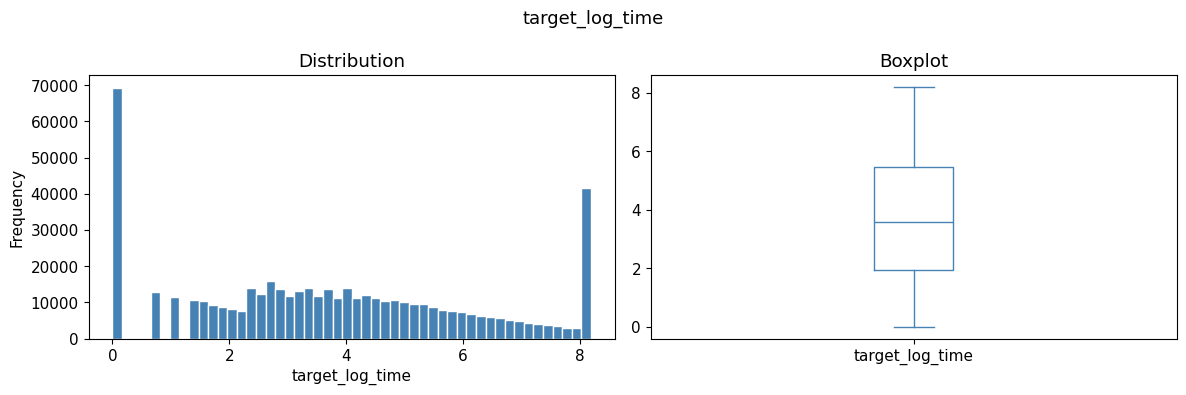

In [24]:
col = "target_log_time"
#df[col] = df[col].fillna(0)
desc_stats(col)

# Split temporel

In [25]:
print(df["date"].min())
print(df["date"].max())

2016-01-02 01:10:41+00:00
2022-12-16 13:17:59+00:00


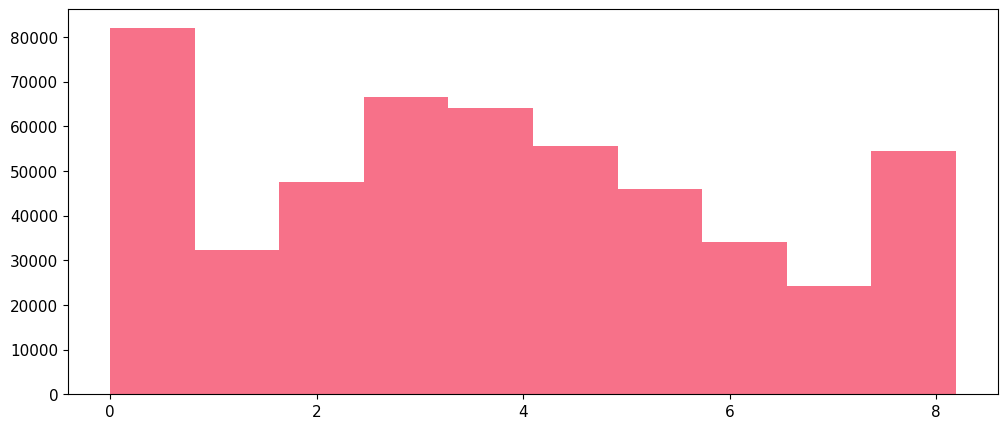

In [26]:
plt.hist(df["target_log_time"])
plt.show()

In [27]:
new = ['season_Automne','season_Hiver','season_Printemps',
        'airport_Ajaccio','airport_Pise','airport_Bastia',
        'airport_Biarritz','airport_Nantes'
        ]
df2 = pd.get_dummies(df)
features = list(set(VAR))
#df2[features] = df2[features].fillna(0)
features += new
df2[new] = df2[new]*1


# train

train = df2[df2["year"] <= 2020]

# validation
val = df2[df2["year"] == 2021]

# test
test = df2[df2["year"] >= 2022]

print("train :",train["date"].min(), train["date"].max())
print("val :",val["date"].min(), val["date"].max())
print("test :",test["date"].min(), test["date"].max())

print(len(features))
X_train = train[features]
y_train = train["target_log_time"]

X_val = val[features]
y_val = val["target_log_time"]

X_test = test[features]
y_test = test["target_log_time"]


train : 2016-01-02 01:10:41+00:00 2020-12-31 23:19:36+00:00
val : 2021-01-01 00:06:55+00:00 2021-12-27 15:12:35+00:00
test : 2022-01-05 13:32:40+00:00 2022-12-16 13:17:59+00:00
63


# Missings?

In [28]:
mis = df2[features].isna().sum()
col_mis = [c for c in mis.index if mis[c]>0]
mis[col_mis]

Series([], dtype: int64)

In [29]:
df.to_csv('output_data.csv', index=False)

In [ ]:
# import joblib
# joblib.dump({
#     "df": df,
#     "VAR": list(set(VAR)),
#     "dumies_vars": new ,
#     'TARGET' : TARGET,
#     'IDS' : IDS
# }, "../data/meteo_data.pkl")

['../data/meteo_data.pkl']